In [1]:
# Shape from Shading - Computer Vision Exercise

## 🧠 Objective:
# Understand how shape from shading works using real image gradients
# and estimate surface normals and depth using a simple model.

import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, filters, exposure
from scipy import ndimage

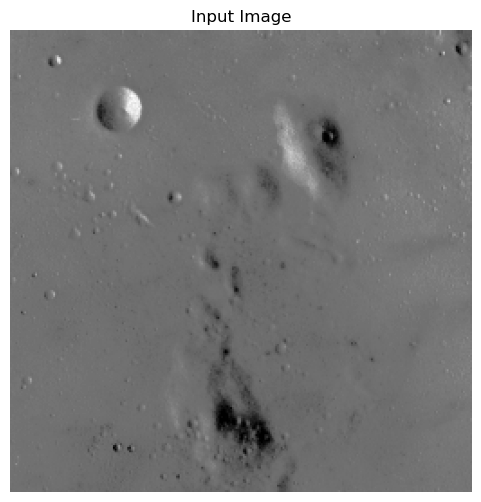

In [2]:
# ---------------------------------------------------------
# 🔹 1. Load and preprocess the image
# ---------------------------------------------------------

# Use a sample image with clear lighting gradient (e.g., moon surface)
image = data.moon()
image = image.astype(np.float32) / 255.0  # Normalize

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

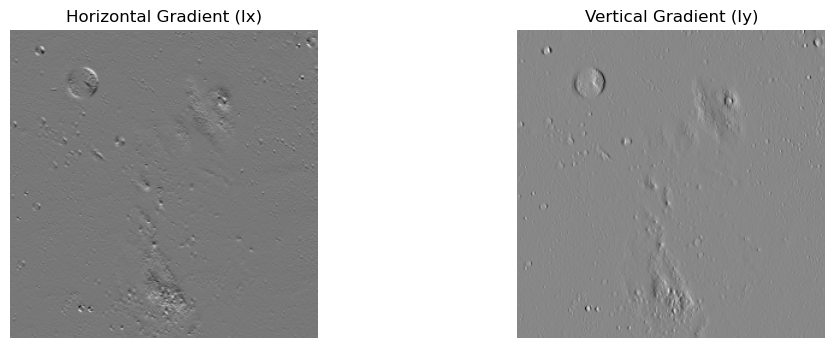

In [3]:
# ---------------------------------------------------------
# 🔹 2. Compute image gradients
# ---------------------------------------------------------

# Use Sobel filters to approximate image gradients (Ix, Iy)
Ix = filters.sobel_h(image)
Iy = filters.sobel_v(image)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(Ix, cmap='gray')
plt.title("Horizontal Gradient (Ix)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(Iy, cmap='gray')
plt.title("Vertical Gradient (Iy)")
plt.axis('off')
plt.show()

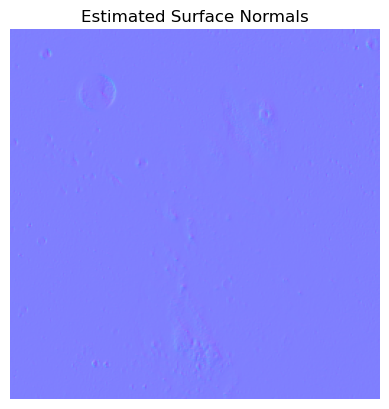

In [4]:
# ---------------------------------------------------------
# 🔹 3. Estimate surface normals (naive method)
# ---------------------------------------------------------

# Assuming: I = n . s, where s = light direction
# Let’s assume s = [0, 0, 1] for simplicity (from viewer)
# Then: n ≈ [-Ix, -Iy, 1], and normalize

Z = np.ones_like(image)
normals = np.stack([-Ix, -Iy, Z], axis=-1)
norm = np.linalg.norm(normals, axis=2, keepdims=True)
normals /= norm

# Visualize one channel of the normals
plt.imshow((normals + 1) / 2)  # normalize for display
plt.title("Estimated Surface Normals")
plt.axis('off')
plt.show()

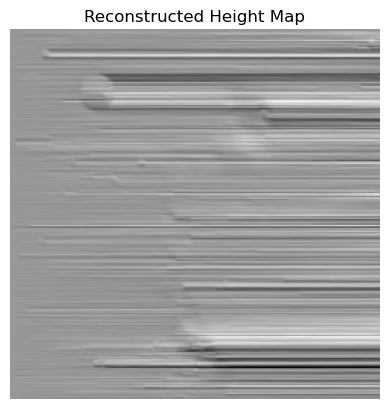

In [5]:
# ---------------------------------------------------------
# 🔹 4. Reconstruct height map (Shape from Shading integration)
# ---------------------------------------------------------

# Integrate gradients using Poisson reconstruction (approximate)
fx = -Ix
fy = -Iy

height_map = np.zeros_like(image)
for y in range(1, image.shape[0]):
    height_map[y, 0] = height_map[y-1, 0] + fy[y, 0]
for x in range(1, image.shape[1]):
    height_map[:, x] = height_map[:, x-1] + fx[:, x]

# Normalize for visualization
height_map_norm = exposure.rescale_intensity(height_map)

plt.imshow(height_map_norm, cmap='gray')
plt.title("Reconstructed Height Map")
plt.axis('off')
plt.show()

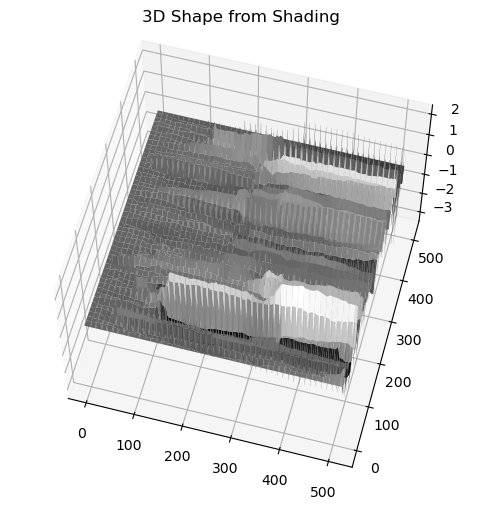

In [6]:
# ---------------------------------------------------------
# 🔹 5. (Optional) 3D Visualization
# ---------------------------------------------------------

from mpl_toolkits.mplot3d import Axes3D

Y, X = np.mgrid[0:height_map.shape[0], 0:height_map.shape[1]]
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, height_map, cmap='gray', edgecolor='none')
ax.set_title("3D Shape from Shading")
ax.view_init(elev=60, azim=-75)
plt.show()

In [7]:
# ---------------------------------------------------------
# ✅ Exercise Questions:
# ---------------------------------------------------------

# Q1: Try changing the light direction vector `s` to other directions (e.g., [1,1,1])
# and observe the effect on the estimated normals and shape.
#
# Q2: Replace the moon image with another grayscale image (e.g., camera, coins).
#
# Q3: Add Gaussian noise to the input image and observe how it affects the result.
#
# Q4: How could this approach be improved to handle real lighting models?